# Chapter 4 — Introduction to Neural Learning: Gradient Descent

**Grokking Deep Learning — Andrew W. Trask**

> Notebook ini mengikuti urutan konsep dan contoh numerik pada *Chapter 4*. Penjelasan dibuat dalam Bahasa Indonesia, sedangkan istilah teknis dan kode dipertahankan sesuai konteks buku.

## Learning Objectives

Setelah menyelesaikan chapter ini, kita dapat:
1. Memahami hubungan **Predict → Compare → Learn**.
2. Menghitung **error** dengan mean squared error.
3. Memahami **hot and cold learning** dan keterbatasannya.
4. Menghitung **delta**, **weight_delta**, dan melakukan **gradient descent**.
5. Memahami **derivative** sebagai kemiringan yang membantu menentukan arah perubahan weight.
6. Memahami **divergence** dan peran **alpha** untuk mengurangi overshooting.

## Chapter Roadmap

Chapter 4 berfokus pada dua tahap yang belum dibahas mendalam pada Chapter 3: **Compare** dan **Learn**.

**Alur utama:**

`Predict → Compare → Learn → update weight → Predict lagi`

Pada chapter ini, pembelajaran dimulai dari contoh neural network yang sangat sederhana dengan satu input dan satu weight.

## 1. Compare: Measuring Error

Setelah network membuat prediction, kita perlu mengukur seberapa jauh prediction tersebut dari `goal_pred`.

Buku menggunakan:

\[
error = (pred - goal\_pred)^2
\]

Pengkuadratan membuat error tidak negatif dan mencegah error positif dan negatif saling membatalkan ketika dirata-ratakan.

In [1]:
knob_weight = 0.5
input = 0.5
goal_pred = 0.8

pred = input * knob_weight
error = (pred - goal_pred) ** 2

print("Prediction:", pred)
print("Error:", error)

Prediction: 0.25
Error: 0.30250000000000005


### Interpretasi

Dengan `input = 0.5` dan `knob_weight = 0.5`, prediction adalah `0.25`. Karena targetnya `0.8`, maka:

\[
error=(0.25-0.8)^2=0.3025
\]

Nilai ini menjadi ukuran seberapa jauh prediction dari target.

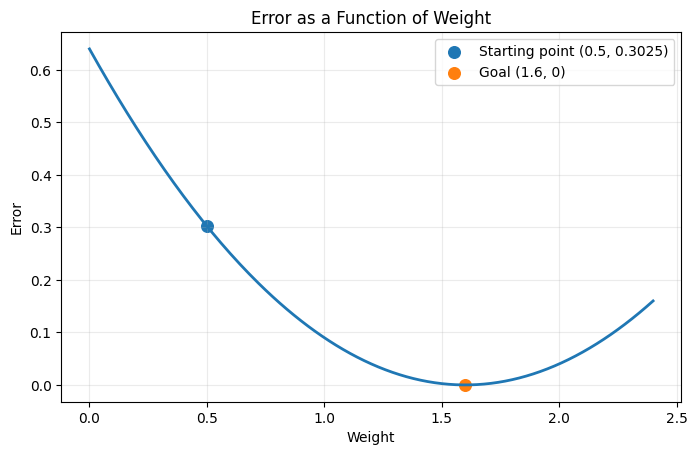

In [2]:
import numpy as np
import matplotlib.pyplot as plt

weights = np.linspace(0, 2.4, 241)
errors = ((0.5 * weights) - 0.8) ** 2

plt.figure(figsize=(8, 4.8))
plt.plot(weights, errors, linewidth=2)
plt.scatter([0.5], [0.3025], s=70, label="Starting point (0.5, 0.3025)")
plt.scatter([1.6], [0.0], s=70, label="Goal (1.6, 0)")
plt.xlabel("Weight")
plt.ylabel("Error")
plt.title("Error as a Function of Weight")
plt.grid(alpha=0.25)
plt.legend()
plt.show()

### Interpretasi kurva

Kurva di atas berasal langsung dari hubungan yang dibahas buku:

\[
error=((0.5	imes weight)-0.8)^2
\]

Titik awal adalah `weight = 0.5` dengan `error = 0.3025`. Titik minimum terjadi pada `weight = 1.6`, ketika prediction tepat menjadi `0.8` dan error menjadi `0`.

Jadi, tujuan learning adalah mencari arah perubahan `weight` yang membawa network menuju bagian dasar kurva.

## 2. Hot and Cold Learning

**Hot and cold learning** mencoba dua arah:
- menaikkan weight sedikit,
- menurunkan weight sedikit,

kemudian memilih arah yang menghasilkan error lebih kecil.

Contoh buku menggunakan `weight = 0.5`, `input = 0.5`, `goal_prediction = 0.8`, dan `step_amount = 0.001`.

In [3]:
weight = 0.5
input = 0.5
goal_prediction = 0.8
step_amount = 0.001

history = []

for iteration in range(1101):
    prediction = input * weight
    error = (prediction - goal_prediction) ** 2
    history.append((iteration, weight, prediction, error))

    up_prediction = input * (weight + step_amount)
    up_error = (goal_prediction - up_prediction) ** 2
    down_prediction = input * (weight - step_amount)
    down_error = (goal_prediction - down_prediction) ** 2

    if down_error < up_error:
        weight = weight - step_amount

    if down_error > up_error:
        weight = weight + step_amount

print("Final weight:", weight)
print("Final prediction:", history[-1][2])
print("Final error:", history[-1][3])

Final weight: 1.6009999999999343
Final prediction: 0.7999999999999672
Final error: 1.0799505792475652e-27


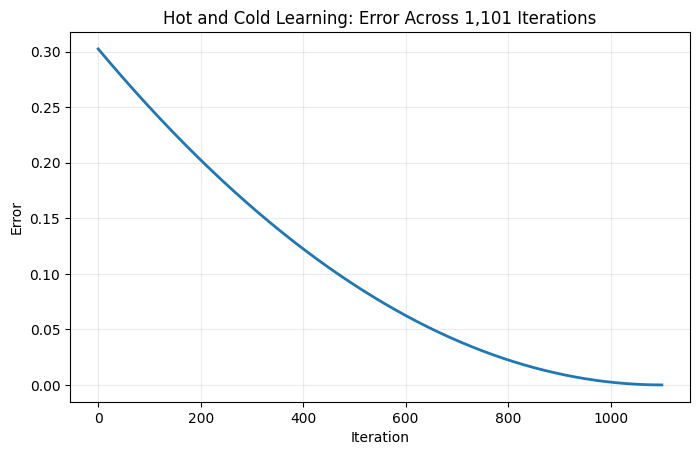

In [4]:
h = np.array(history)

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.plot(h[:, 0], h[:, 3], linewidth=2)
ax.set_xlabel("Iteration")
ax.set_ylabel("Error")
ax.set_title("Hot and Cold Learning: Error Across 1,101 Iterations")
ax.grid(alpha=0.25)
plt.show()

### Keterbatasan Hot and Cold Learning

Sesuai pembahasan buku, metode ini sederhana tetapi:
- membutuhkan beberapa prediction untuk satu update weight,
- `step_amount` bersifat tetap,
- dapat mengalami overshooting atau bolak-balik jika ukuran langkah tidak sesuai.

Karena itu, chapter beralih ke metode yang dapat menghitung **arah dan jumlah perubahan weight** secara langsung.

## 3. Gradient Descent

Buku memperkenalkan bentuk yang lebih efisien:

\[
direction\_and\_amount=(pred-goal\_pred)	imes input
\]

Kemudian:

\[
weight = weight - direction\_and\_amount
\]

Komponen `(pred - goal_pred)` disebut **pure error**. Perkalian dengan `input` memberikan efek scaling, negative reversal, dan stopping yang dibahas buku.

In [5]:
weight = 0.5
goal_pred = 0.8
input = 0.5

gd_history = []

for iteration in range(20):
    pred = input * weight
    error = (pred - goal_pred) ** 2
    direction_and_amount = (pred - goal_pred) * input
    weight = weight - direction_and_amount
    gd_history.append((iteration, weight, pred, error))

print("First 5 iterations:")
for row in gd_history[:5]:
    print(row)

First 5 iterations:
(0, 0.775, 0.25, 0.30250000000000005)
(1, 0.9812500000000001, 0.3875, 0.17015625000000004)
(2, 1.1359375, 0.49062500000000003, 0.095712890625)
(3, 1.251953125, 0.56796875, 0.05383850097656251)
(4, 1.33896484375, 0.6259765625, 0.03028415679931642)


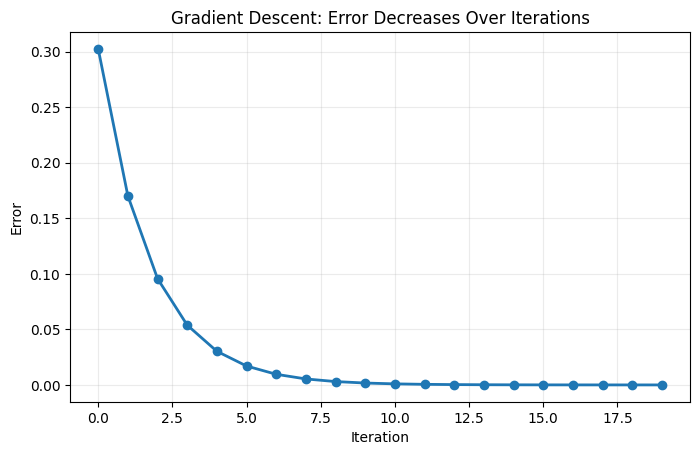

Last prediction: 0.7976744445781151
Last error: 5.408208020258491e-06


In [6]:
g = np.array(gd_history)

fig, ax1 = plt.subplots(figsize=(8, 4.8))
ax1.plot(g[:, 0], g[:, 3], marker="o", linewidth=2, label="Error")
ax1.set_xlabel("Iteration")
ax1.set_ylabel("Error")
ax1.set_title("Gradient Descent: Error Decreases Over Iterations")
ax1.grid(alpha=0.25)
plt.show()

print("Last prediction:", g[-1, 2])
print("Last error:", g[-1, 3])

## 4. One Iteration of Gradient Descent

Buku kemudian memecah proses learning menjadi bagian yang lebih jelas:

1. **PREDICT** → hitung `pred`.
2. **COMPARE** → hitung `error`.
3. Hitung `delta = pred - goal_pred`.
4. Hitung `weight_delta = input * delta`.
5. **LEARN** → update `weight`.

Contoh pada buku menggunakan `number_of_toes = 8.5`, target `1`, dan `weight = 0.1`, sehingga prediction `0.85`, `delta = -0.15`, dan `weight_delta = -1.25`.

In [7]:
number_of_toes = [8.5]
win_or_lose_binary = [1]

input = number_of_toes[0]
goal_pred = win_or_lose_binary[0]
weight = 0.1

pred = input * weight
error = (pred - goal_pred) ** 2
delta = pred - goal_pred
weight_delta = input * delta

print("Prediction:", pred)
print("Error:", error)
print("Delta:", delta)
print("Weight delta:", weight_delta)

Prediction: 0.8500000000000001
Error: 0.022499999999999975
Delta: -0.1499999999999999
Weight delta: -1.2749999999999992


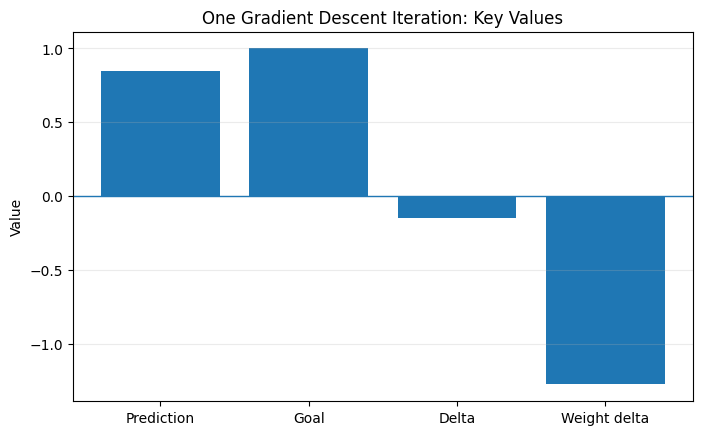

In [8]:
labels = ["Prediction", "Goal", "Delta", "Weight delta"]
values = [pred, goal_pred, delta, weight_delta]

plt.figure(figsize=(8, 4.8))
plt.bar(labels, values)
plt.axhline(0, linewidth=1)
plt.ylabel("Value")
plt.title("One Gradient Descent Iteration: Key Values")
plt.grid(axis="y", alpha=0.25)
plt.show()

## 5. The Error Surface and Derivative

Buku menunjukkan bahwa untuk hubungan:

\[
error=((0.5	imes weight)-0.8)^2
\]

setiap nilai `weight` memiliki nilai error tertentu. Kurvanya berbentuk seperti mangkuk.

**Derivative** menunjukkan seberapa cepat error berubah ketika `weight` berubah. Gradient descent bergerak berlawanan arah dengan derivative agar mendekati minimum error.

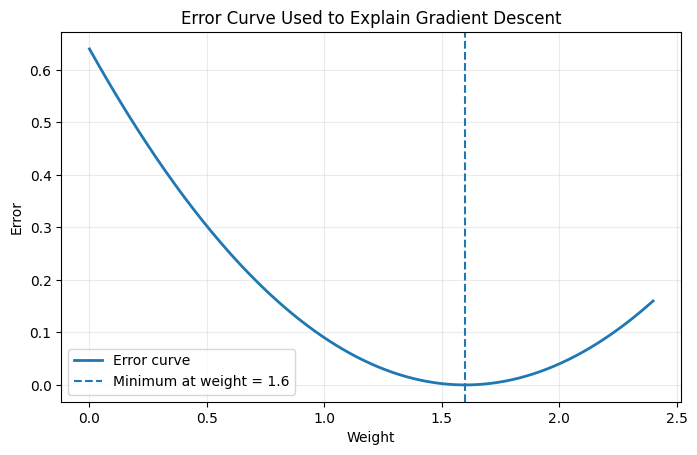

In [9]:
weight_values = np.linspace(0, 2.4, 241)
error_values = ((0.5 * weight_values) - 0.8) ** 2
derivative_values = weight_values / 2 - 0.8

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.plot(weight_values, error_values, linewidth=2, label="Error curve")
ax.axvline(1.6, linestyle="--", linewidth=1.5, label="Minimum at weight = 1.6")
ax.set_xlabel("Weight")
ax.set_ylabel("Error")
ax.set_title("Error Curve Used to Explain Gradient Descent")
ax.grid(alpha=0.25)
ax.legend()
plt.show()

## 6. Breaking Gradient Descent: Divergence

Buku menunjukkan bahwa gradient descent dapat mengalami **divergence** ketika `input` terlalu besar.

Contoh yang digunakan:

```python
weight = 0.5
goal_pred = 0.8
input = 2
```

Tanpa `alpha`, update menjadi terlalu besar sehingga prediction bergantian melewati target dan nilainya semakin jauh.

In [10]:
weight = 0.5
goal_pred = 0.8
input = 2

div_history = []

for iteration in range(12):
    pred = input * weight
    error = (pred - goal_pred) ** 2
    delta = pred - goal_pred
    weight_delta = input * delta
    div_history.append((iteration, weight, pred, error))
    weight = weight - weight_delta

d = np.array(div_history)

print("Iteration | Weight | Prediction | Error")
for row in d:
    print(f"{int(row[0]):9d} | {row[1]:.4g} | {row[2]:.4g} | {row[3]:.4g}")

Iteration | Weight | Prediction | Error
        0 | 0.5 | 1 | 0.04
        1 | 0.1 | 0.2 | 0.36
        2 | 1.3 | 2.6 | 3.24
        3 | -2.3 | -4.6 | 29.16
        4 | 8.5 | 17 | 262.4
        5 | -23.9 | -47.8 | 2362
        6 | 73.3 | 146.6 | 2.126e+04
        7 | -218.3 | -436.6 | 1.913e+05
        8 | 656.5 | 1313 | 1.722e+06
        9 | -1968 | -3936 | 1.55e+07
       10 | 5905 | 1.181e+04 | 1.395e+08
       11 | -1.771e+04 | -3.543e+04 | 1.255e+09


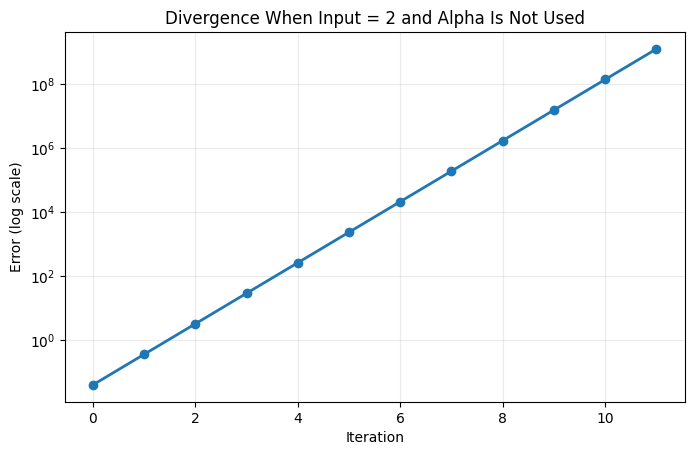

In [11]:
fig, ax = plt.subplots(figsize=(8, 4.8))
ax.semilogy(d[:, 0], d[:, 3], marker="o", linewidth=2)
ax.set_xlabel("Iteration")
ax.set_ylabel("Error (log scale)")
ax.set_title("Divergence When Input = 2 and Alpha Is Not Used")
ax.grid(alpha=0.25)
plt.show()

### Mengapa terjadi divergence?

Ketika input besar, prediction sangat sensitif terhadap perubahan weight. Akibatnya, `weight_delta` dapat menjadi terlalu besar. Update berikutnya justru semakin jauh dari target.

Ini adalah **overshooting** yang berulang dan menghasilkan divergence.

## 7. Introducing Alpha

Buku memperkenalkan **alpha** untuk memperkecil ukuran weight update:

\[
weight = weight - (lpha 	imes derivative)
\]

Pada contoh yang sebelumnya mengalami divergence, buku menggunakan:

```python
weight = 0.5
goal_pred = 0.8
input = 2
alpha = 0.1
```

Dengan alpha, perubahan weight menjadi lebih kecil sehingga learning dapat mendekati target.

In [12]:
weight = 0.5
goal_pred = 0.8
input = 2
alpha = 0.1

alpha_history = []

for iteration in range(20):
    pred = input * weight
    error = (pred - goal_pred) ** 2
    derivative = input * (pred - goal_pred)
    alpha_history.append((iteration, weight, pred, error))
    weight = weight - (alpha * derivative)

a = np.array(alpha_history)

print("First 3:")
for row in a[:3]:
    print(f"iteration={int(row[0])}, weight={row[1]:.12f}, prediction={row[2]:.12f}, error={row[3]:.12g}")

print("\nLast 3:")
for row in a[-3:]:
    print(f"iteration={int(row[0])}, weight={row[1]:.12f}, prediction={row[2]:.12f}, error={row[3]:.12g}")

First 3:
iteration=0, weight=0.500000000000, prediction=1.000000000000, error=0.04
iteration=1, weight=0.460000000000, prediction=0.920000000000, error=0.0144
iteration=2, weight=0.436000000000, prediction=0.872000000000, error=0.005184

Last 3:
iteration=17, weight=0.400016926659, prediction=0.800033853319, error=1.14604719983e-09
iteration=18, weight=0.400010155996, prediction=0.800020311991, error=4.12576991939e-10
iteration=19, weight=0.400006093597, prediction=0.800012187195, error=1.48527717099e-10


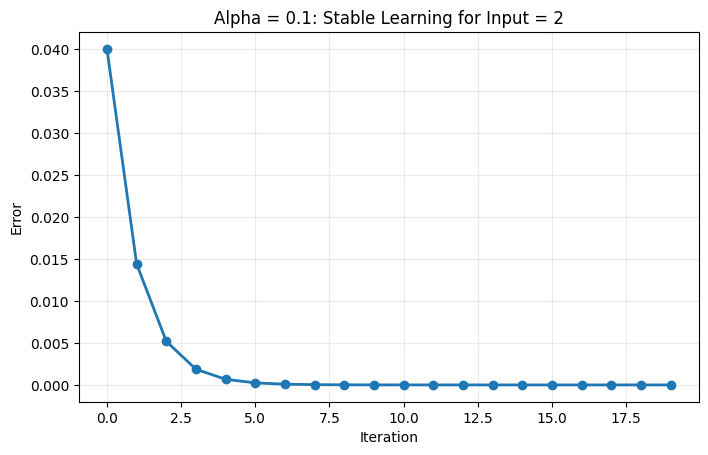

In [13]:
fig, ax = plt.subplots(figsize=(8, 4.8))
ax.plot(a[:, 0], a[:, 3], marker="o", linewidth=2)
ax.set_xlabel("Iteration")
ax.set_ylabel("Error")
ax.set_title("Alpha = 0.1: Stable Learning for Input = 2")
ax.grid(alpha=0.25)
plt.show()

### Memilih Alpha

Buku menjelaskan bahwa pemilihan alpha sering dilakukan dengan mencoba beberapa orde besaran seperti:

`10, 1, 0.1, 0.01, 0.001, 0.0001`

Jika error mulai divergen, alpha terlalu besar dan perlu diturunkan. Jika learning terlalu lambat, alpha terlalu kecil dan dapat dinaikkan.

Jadi, **alpha mengontrol seberapa agresif weight diperbarui**.

## Concept Check

| Konsep | Inti pemahaman |
|---|---|
| Compare | Mengukur seberapa jauh prediction dari target |
| Error | Pada contoh chapter ini menggunakan squared error |
| Hot and cold learning | Mencoba perubahan kecil ke atas dan ke bawah |
| Delta | `pred - goal_pred` |
| Weight delta | `input * delta` |
| Gradient descent | Mengubah weight berlawanan arah dengan gradient |
| Derivative | Menunjukkan laju perubahan error terhadap weight |
| Divergence | Update terlalu besar sehingga error semakin menjauh |
| Alpha | Memperkecil ukuran update weight |

## Key Takeaways

- **Predict** saja belum cukup; network harus **Compare** prediction dengan target.
- Error pada chapter ini dihitung menggunakan squared error.
- **Hot and cold learning** menunjukkan ide dasar pencarian arah perubahan weight, tetapi tidak efisien.
- **Gradient descent** menghitung arah dan besarnya perubahan weight dengan lebih langsung.
- **Derivative** memberi informasi tentang arah perubahan error.
- Input yang besar dapat menyebabkan **overshooting** dan **divergence**.
- **Alpha** digunakan untuk mengontrol ukuran weight update agar learning lebih stabil.

## Chapter Summary

Chapter 4 membawa alur dari:

**Predict → Compare → Learn**

Pada bagian Compare, network mengukur error. Pada bagian Learn, network menentukan bagaimana weight harus diubah untuk menurunkan error. Dari hot and cold learning, pembahasan berkembang menuju gradient descent, derivative, divergence, dan alpha.

Chapter berikutnya memperluas gradient descent agar dapat menangani **multiple weights** secara bersamaan.

## Reference

Trask, A. W. *Grokking Deep Learning*. Manning Publications.

**Source basis:** Chapter 4, *Introduction to Neural Learning: Gradient Descent*, terutama bagian Compare, Hot and Cold Learning, Gradient Descent, Derivatives, Breaking Gradient Descent, Divergence, dan Alpha.